# Project: Zero-Coupon Curve Construction & OIS Interpolation

In [14]:
import numpy as np 
from scipy.interpolate import CubicSpline
import pandas as pd 
import matplotlib.pyplot as plt

In [15]:
class OISCurveBootstrapper: 
    def __init__(self, deposits, swaps, day_count='ACT/360'): 
        self.deposits = deposits
        self.swaps = swaps 
        self.day_count = day_count
        self.discount_factors = {}

    def bootstrap(self): 
        for tenor_days, rate in self.deposits: 
            T = tenor_days / 360.0
            self.discount_factors[T] = 1.0 / (1 + rate * T)
        
        for maturity, par_rate, freq in self.swaps: 
            payment_times = np.linspace(freq, maturity, int(maturity/freq))
            known_pv = 0.0
            last_T = payment_times[-1]
        
            for t in payment_times[:-1]: 
                delta = freq
                known_pv += par_rate * delta * self.discount_factors.get(t, 1.0)

            last_delta = freq
            self.discount_factors[last_T] = (1 - known_pv) / (1 + par_rate * last_delta)

        return self.discount_factors
    
    def interpolate_curve(self, fine_grid): 
        known_T = sorted(self.discount_factors.keys())
        known_df = [self.discount_factors[T] for T in known_T]
        log_df = np.log(known_df)
        cs = CubicSpline(known_T, log_df)
        return {T: np.exp(cs(T)) for T in fine_grid}

def compute_forward_rate(P, T1, T2): 
    delta = T2 - T1 
    return (P[T1]/P[T2] - 1) / delta

In [16]:
deposits = [
    (1, 0.0050),   # ON
    (7, 0.0051),   # 1W
    (30, 0.0052),  # 1M 
    ]

swaps = [
    (0.25, 0.0055, 0.25),  # 3M
    (0.50, 0.0060, 0.25),  # 6M
    (1.00, 0.0070, 0.25),  # 1Y
    (2.00, 0.0085, 0.25),  # 2Y
    (5.00, 0.0120, 0.25),  # 5Y
    (10.0, 0.0150, 0.25),  # 10Y
]

In [17]:
boot = OISCurveBootstrapper(deposits, swaps)
dfs_bootstrapped = boot.bootstrap()

fine_grid = np.round(np.arange(1/12, 10 + 1e-9, 1/12), 10)
curve = boot.interpolate_curve(fine_grid)

In [18]:
df_table = pd.DataFrame(
    {"T (years)": list(curve.keys()), "P(0,T)": list(curve.values())}
).sort_values("T (years)")

df_table["ZeroRate_cc"] = -np.log(df_table["P(0,T)"]) / df_table["T (years)"]

In [19]:
Ts = df_table["T (years)"].values
fwds = []
for i in range(1, len(Ts)):
    T1, T2 = float(Ts[i-1]), float(Ts[i])
    fwds.append(
        {"T1": T1, "T2": T2, "FwdRate_simple": compute_forward_rate(curve, T1, T2)}
    )
fwd_table = pd.DataFrame(fwds)

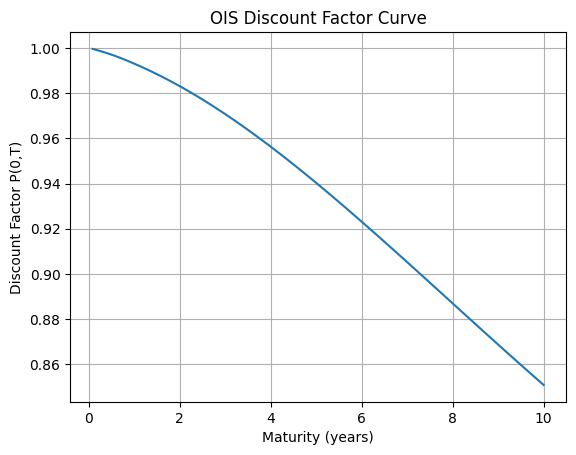

In [21]:
plt.figure()
plt.plot(df_table["T (years)"], df_table["P(0,T)"])
plt.xlabel("Maturity (years)")
plt.ylabel("Discount Factor P(0,T)")
plt.title("OIS Discount Factor Curve")
plt.grid(True)
plt.show()